## Wills Kookogey PyTorch Learning Enviromnment

### Setup and Hyperparameters

Vars of interest

"IMU_0":["GyrX", "GyrY", "GyrZ", "AccX", "AccY", "AccZ"],
"ATT":["DesRoll", "Roll"]

In [ ]:
import fennec_ml as fn
import FID_utils as FID
import json
import os
from pathlib import Path
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms  as transforms
import matplotlib.pyplot as plt
%matplotlib inline

# hyper parameters
train_split = 0.8
input_size = 8
hidden_size = 64
num_classes = 4
num_epochs = 50
batch_size = 100
test_batch_size = 1
learning_rate = 0.001
weight_decay = 1e-3
dropout = 0.3
patience = 5  # number of epochs to wait for improvement before early stopping

sequence_length = 80
num_layers = 2

model_name = "fid_model_3_1.pth"

### Folder Config

In [ ]:
# folder config
main_dir = os.getcwd()
data_dir = os.path.join(main_dir, "DATA")
os.makedirs(data_dir, exist_ok=True)
excel_dir = os.path.join(data_dir, "RAW_DATA/FID_2")
os.makedirs(excel_dir, exist_ok=True)
csv_dir = os.path.join(data_dir, "PROCESSED_DATA/FID_2")
test_csv_dir = os.path.join(csv_dir, "test_flights")
os.makedirs(csv_dir, exist_ok=True)
os.makedirs(test_csv_dir, exist_ok=True)

json_path = os.path.join(main_dir, "vars_of_interest.json")

# Create models directory 
model_path = Path("models")
model_path.mkdir(parents=True, exist_ok=True)

# Create model save path
model_save_path = model_path / model_name

# convert excel data to csv
# print("Using folder_cleaner() to convert from raw excel files to .csv's only including vars of interest.\nfolder_cleaner() output:")
# fnw.folder_cleaner(excel_dir, csv_dir, overwrite=True, downsample=False)

# convert csv to numpy arrays
# SLICED DATA TO START AT 400 bc that's after the latest leak started (latest leak started at 342)
train_val_data = fn.csv_to_numpy(csv_dir, start_index=16000) 
test_data = fn.csv_to_numpy(test_csv_dir, start_index=16000)

# split data to train/validation/test sets
# I BELIEVE THIS FUNCTION NO LONGER EXISTS CAUSE THE DATA WAS BEING IMPROPERLY SPLIT. THE MOST RECENT/FIXED DATA PIPELINE IS IN THE FID4_... CODES.
train_data, val_data = fn.split_train_val(train_val_data, train_split)

# standardize data
train_data, val_data, test_data = fn.scale(train_data, val_data, test_data, scaler="standard")

# get FID labels
train_val_labels = FID.get_FID_labels(csv_dir)
test_labels = FID.get_FID_labels(test_csv_dir)

# verify flights found
num_train_val_flights = len(train_val_labels)
print(f"Found {num_train_val_flights} flights for training and validation")

num_test_flights = len(test_labels)
print(f"Found {num_test_flights} flights for testing")

# segment and label data
# I BELIEVE THIS FUNCTION NO LONGER EXISTS CAUSE THE DATA WAS BEING IMPROPERLY SPLIT. THE MOST RECENT/FIXED DATA PIPELINE IS IN THE FID4_... CODES.
dataset_dict = fn.segment_and_label(train_data, val_data, test_data, train_val_labels, train_val_labels, test_labels, sequence_length, shuffle=True)

Found 12 flights for training and validation
Found 4 flights for testing
segments shuffled
segments shuffled
Segments not shuffled
All data segmented and labeled!
Training_Sets: 3876
Validation_Sets: 965
Testing_Sets: 1577


### Check Data Shape

In [15]:
print(dataset_dict["Training_Set"]["sets"].shape)
print(dataset_dict["Training_Set"]["labels"].shape)
print(dataset_dict["Validation_Set"]["sets"].shape)
print(dataset_dict["Validation_Set"]["labels"].shape)
print(dataset_dict["Testing_Set"]["sets"].shape)
print(dataset_dict["Testing_Set"]["labels"].shape)

(3876, 80, 8)
(3876,)
(965, 80, 8)
(965,)
(1577, 80, 8)
(1577,)


### Convert data to tensors

In [16]:
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, TensorDataset
import numpy as np

encoder = LabelEncoder()

encoded_labels_train = encoder.fit_transform(dataset_dict["Training_Set"]["labels"])
print(encoder.classes_)
encoded_labels_val   = encoder.transform(dataset_dict["Validation_Set"]["labels"])
encoded_labels_test  = encoder.transform(dataset_dict["Testing_Set"]["labels"])

input_train = torch.from_numpy(dataset_dict["Training_Set"]["sets"]).type(torch.float)
output_train = torch.from_numpy(encoded_labels_train).long()

input_val = torch.from_numpy(dataset_dict["Validation_Set"]["sets"]).type(torch.float)
output_val = torch.from_numpy(encoded_labels_val).long()

input_test = torch.from_numpy(dataset_dict["Testing_Set"]["sets"]).type(torch.float)
output_test = torch.from_numpy(encoded_labels_test).long()

# stack inputs and outputs
train_data = TensorDataset(input_train, output_train)
val_data = TensorDataset(input_val, output_val)
test_data = TensorDataset(input_test, output_test)

# data loader
class_counts = np.bincount(output_train.numpy())
print(f'Num data segments per class: {class_counts}')
weights = 1. / class_counts
print(f'Weights per class: {weights}')
sample_weights = [weights[label] for label in output_train]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# try shuffle = false
train_loader = DataLoader(train_data, batch_size=batch_size, sampler=sampler)
val_loader   = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=test_batch_size, shuffle=False)

['L' 'LR' 'NONE' 'R']
Num data segments per class: [1067 1085  865  859]
Weights per class: [0.00093721 0.00092166 0.00115607 0.00116414]


### Build Model

In [17]:
from pathlib import Path
import torch
import torch.nn as nn
from torch.optim import Adam
import torchvision.transforms  as transforms
import matplotlib.pyplot as plt
%matplotlib inline

# Device config
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("MPS device found.")
else:
    print("MPS device not found. Using CPU.")
    device = torch.device("cpu") # Fallback to CPU if MPS is not available

# GRU Model
class GRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=dropout):
        super(GRU, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                          batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_size // 2, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        # GRU output
        out, _ = self.gru(x)   # out: [batch, seq, hidden]
        
        # Take only the last timestep
        out = out[:, -1, :]    # [batch, hidden]

        # Fully connected layers with dropout
        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)

        return out

model = GRU(input_size=input_size, hidden_size=hidden_size, num_classes=num_classes, num_layers=num_layers).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
best_val_loss = float('inf')

MPS device found.


### Train Model

Epoch 1/50, Train Loss: 1.3827, Val Loss: 1.3853, Val Acc: 0.3026
✅ Saved best model at epoch 1
Epoch 2/50, Train Loss: 1.3736, Val Loss: 1.3657, Val Acc: 0.3275
✅ Saved best model at epoch 2
Epoch 3/50, Train Loss: 1.3701, Val Loss: 1.3721, Val Acc: 0.3161
Epoch 4/50, Train Loss: 1.3632, Val Loss: 1.3570, Val Acc: 0.3316
✅ Saved best model at epoch 4
Epoch 5/50, Train Loss: 1.3555, Val Loss: 1.3762, Val Acc: 0.3534
Epoch 6/50, Train Loss: 1.3570, Val Loss: 1.3567, Val Acc: 0.3513
✅ Saved best model at epoch 6
Epoch 7/50, Train Loss: 1.3441, Val Loss: 1.3416, Val Acc: 0.3544
✅ Saved best model at epoch 7
Epoch 8/50, Train Loss: 1.3283, Val Loss: 1.3047, Val Acc: 0.3948
✅ Saved best model at epoch 8
Epoch 9/50, Train Loss: 1.2584, Val Loss: 1.1582, Val Acc: 0.4508
✅ Saved best model at epoch 9
Epoch 10/50, Train Loss: 1.1765, Val Loss: 1.0570, Val Acc: 0.4943
✅ Saved best model at epoch 10
Epoch 11/50, Train Loss: 1.1190, Val Loss: 1.0348, Val Acc: 0.4839
✅ Saved best model at epoch 11


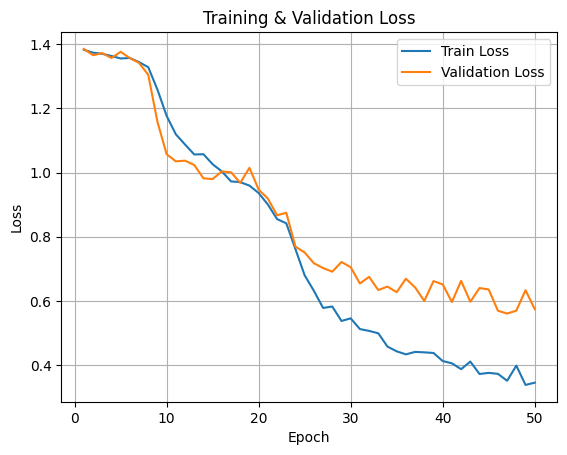

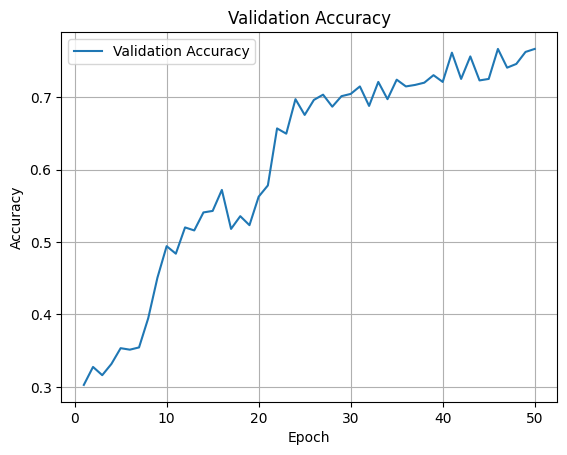

In [18]:
# Train Loop

# arrays to store training curve data
train_losses = []
val_losses = []
val_accuracies = []

no_improvement_epochs = 0

model.train()

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0
    for input, output in train_loader:
        # print(f"Input shape: {input.shape}, Output shape: {output.shape}")
        input, output = input.to(device), output.to(device)
        optimizer.zero_grad()
        model_outputs = model(input)
        loss = criterion(model_outputs,output)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * input.size(0)
    epoch_loss = running_loss / len(train_data)

    # Validation
    model.eval()
    val_loss = 0
    correct = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs,y_batch)
            val_loss += loss.item() * X_batch.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y_batch).sum().item()
    val_loss /= len(val_data)
    val_acc = correct / len(val_data)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    # save each epoch's perormance
    train_losses.append(epoch_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), model_save_path)
        print(f"✅ Saved best model at epoch {epoch+1}")
        no_improvement_epochs = 0 # reset counter if model improves
    
    else:
        no_improvement_epochs += 1
        if no_improvement_epochs >= patience:
            print("⏰ Early stopping")
            break

print("Training complete!")

epochs = range(1, len(train_losses) + 1)

# plot training and validation loss curves

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### Plot Confusion Matrix / Confidence Interval for Seen Flights

Accuracy on Seen Flights: 74.09%


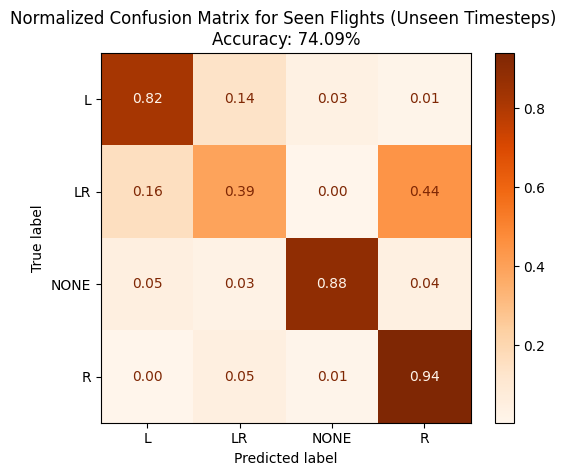

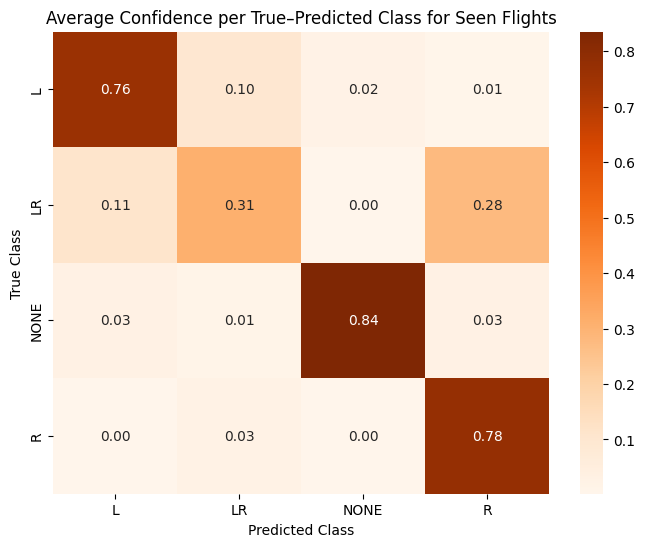

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

true_classes = encoder.classes_

correct_guesses = 0
total_guesses = 0
correctness = 0

all_true = []
all_preds = []
all_probs = []
all_confidences = []

model.load_state_dict(torch.load(model_save_path))
model.to(device)
model.eval()

for inputs, labels in val_loader:   # each iteration = 1 file dataset tensor
    inputs = inputs.to(device)
    labels = labels.to(device)
    
    with torch.no_grad():
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        confs, preds = torch.max(probs, dim=1)

        all_true.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_confidences.extend(confs.cpu().numpy())

# Compute Accuracy
all_true = np.array(all_true)
all_preds = np.array(all_preds)
accuracy = np.mean(all_true == all_preds)
print(f"Accuracy on Seen Flights: {accuracy:.2%}")

# Plot Confusion Matrix
cm = confusion_matrix(all_true, all_preds, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=true_classes)
disp.plot(cmap='Oranges', values_format=".2f")
plt.title(f"Normalized Confusion Matrix for Seen Flights (Unseen Timesteps) \nAccuracy: {accuracy:.2%}")
plt.show()

# ---- Step 4: Average Confidence Matrix ---- #
n_classes = len(true_classes)
conf_matrix = np.zeros((n_classes, n_classes))

for t, p, c in zip(all_true, all_preds, all_confidences):
    conf_matrix[t, p] += c

counts = np.bincount(all_true, minlength=n_classes)
conf_matrix = conf_matrix / counts[:, None]

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt=".2f", cmap="Oranges",
            xticklabels=true_classes, yticklabels=true_classes)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Average Confidence per True–Predicted Class for Seen Flights")

plt.show()

### Calculate Confusion Matrix / Confidence Interval for Unseen Flights

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

true_classes = encoder.classes_

correct_guesses = 0
total_guesses = 0
correctness = 0

all_true = []
all_preds = []
all_probs = []
all_loss = []
all_confidences = []

model.load_state_dict(torch.load(model_save_path))
model.to(device)
model.eval()

for input, label in test_loader:   # each iteration = 1 file dataset tensor
    input = input.to(device)
    # label = label.to(device)
    
    with torch.no_grad():
        outputs = model(input)
        # loss = criterion(outputs, label)
        probs = torch.softmax(outputs, dim=1)
        confs, preds = torch.max(probs, dim=1)

        all_true.extend(label.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        # all_loss.append(loss.item())
        all_confidences.extend(confs.cpu().numpy())

### Plot Correctness / Confidence CM for Unseen Flights

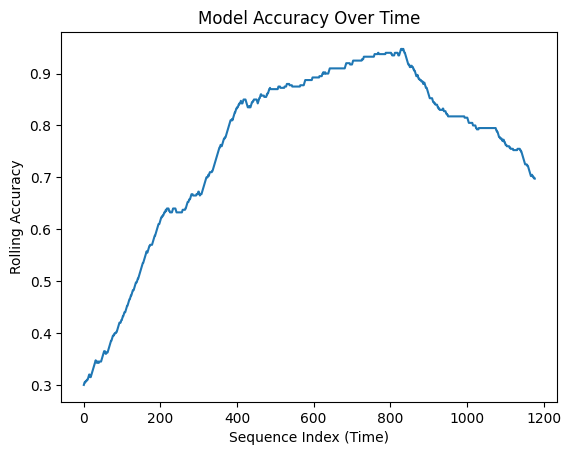

Accuracy on Unseen Flights: 68.86%
Unique true: [0 1 2 3]
Unique preds: [0 1 2 3]
Num classes: 4


<Figure size 800x600 with 0 Axes>

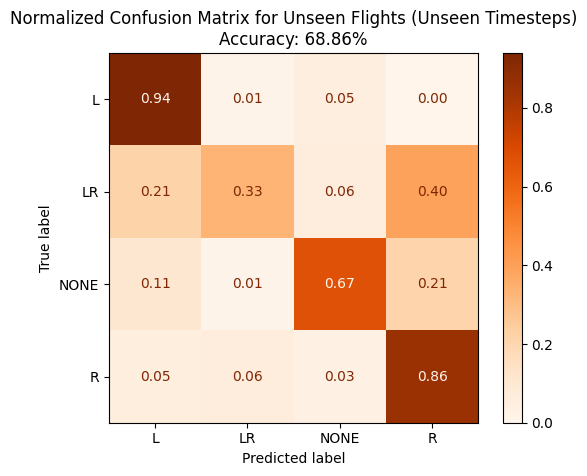

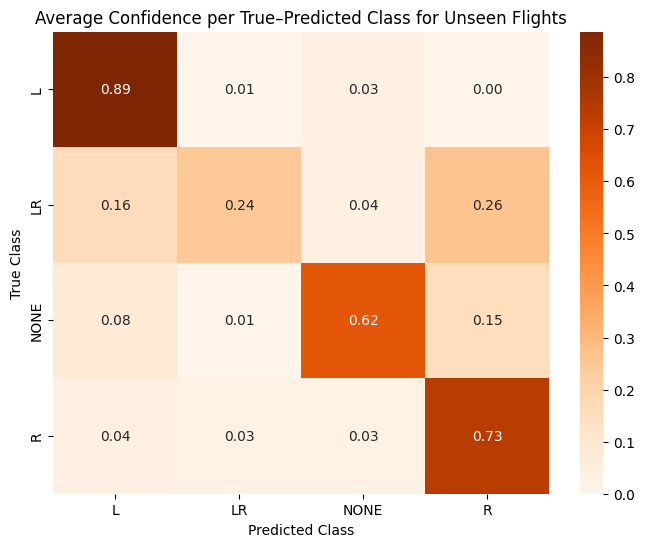

In [22]:
# Compute sequential correctness
correct = np.array(all_preds) == np.array(all_true)

# calculate rolling accuracy for smoothness
window = 400
rolling_acc = np.convolve(correct, np.ones(window) / window, mode="valid")

# plot rolling accuracy
plt.figure()
plt.plot(rolling_acc)
plt.xlabel("Sequence Index (Time)")
plt.ylabel("Rolling Accuracy")
plt.title("Model Accuracy Over Time")
plt.show()

# Compute Avg Accuracy
all_true = np.array(all_true)
all_preds = np.array(all_preds)
accuracy = np.mean(all_true == all_preds)
print(f"Accuracy on Unseen Flights: {accuracy:.2%}")

print("Unique true:", np.unique(all_true))
print("Unique preds:", np.unique(all_preds))
print("Num classes:", len(true_classes))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(all_true, all_preds, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=true_classes)
disp.plot(cmap='Oranges', values_format=".2f")
plt.title(f"Normalized Confusion Matrix for Unseen Flights (Unseen Timesteps)\nAccuracy: {accuracy:.2%}")
plt.show()

# ---- Step 4: Average Confidence Matrix ---- #
n_classes = len(true_classes)
conf_matrix = np.zeros((n_classes, n_classes))

for t, p, c in zip(all_true, all_preds, all_confidences):
    conf_matrix[t, p] += c

counts = np.bincount(all_true, minlength=n_classes)
conf_matrix = conf_matrix / counts[:, None]

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt=".2f", cmap="Oranges",
            xticklabels=true_classes, yticklabels=true_classes)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Average Confidence per True–Predicted Class for Unseen Flights")
plt.show()